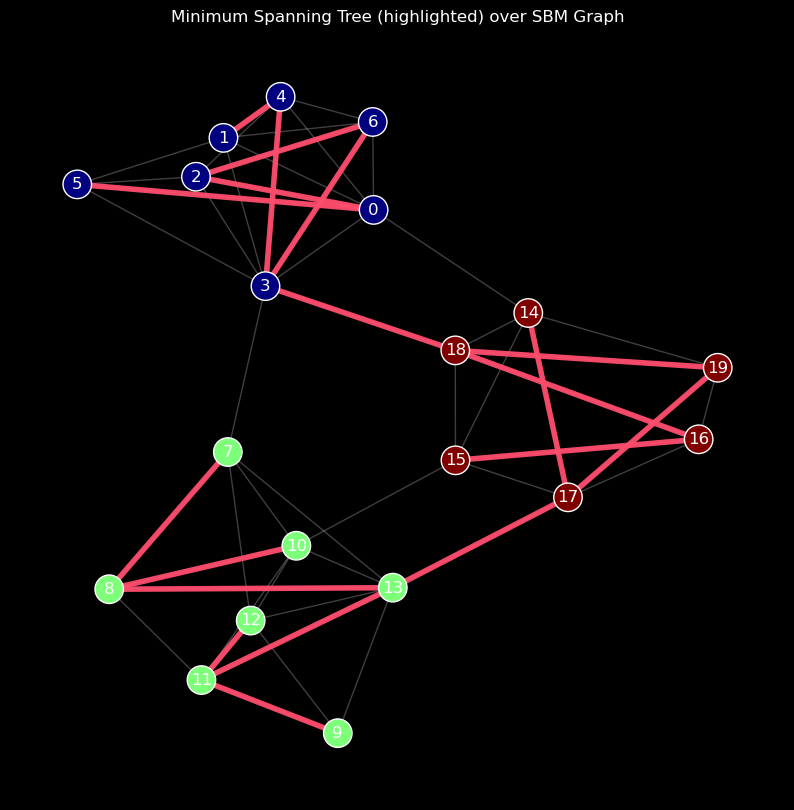

Used seed: 42
MST has 20 nodes and 19 edges
Total MST weight: 28.759
MST edges (u, v, weight):
  ( 0,  5)  w=1.075
  ( 0,  2)  w=1.351
  ( 1,  4)  w=1.102
  ( 2,  6)  w=1.355
  ( 3,  6)  w=1.051
  ( 3,  4)  w=1.182
  ( 3, 18)  w=4.505
  ( 7,  8)  w=1.284
  ( 8, 13)  w=1.035
  ( 8, 10)  w=1.156
  ( 9, 11)  w=1.123
  (11, 13)  w=1.104
  (11, 12)  w=1.152
  (13, 17)  w=4.182
  (14, 17)  w=1.350
  (15, 16)  w=1.250
  (16, 18)  w=1.231
  (17, 19)  w=1.112
  (18, 19)  w=1.160


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

plt.style.use("dark_background")

def generate_community_graph(
    n_nodes: int,
    n_communities: int,
    p_intra: float,
    p_inter: float,
    seed: int = None
):
    if seed is not None:
        np.random.seed(seed)

    sizes = [n_nodes // n_communities] * n_communities
    remainder = n_nodes % n_communities
    for i in range(remainder):
        sizes[i] += 1

    probs = np.full((n_communities, n_communities), p_inter)
    np.fill_diagonal(probs, p_intra)

    G = nx.stochastic_block_model(sizes, probs, seed=seed)

    labels = []
    for comm_id, size in enumerate(sizes):
        labels.extend([comm_id] * size)

    return G, np.asarray(labels)

def ensure_connected_sbm(
    n_nodes=20, n_communities=3, p_intra=0.8, p_inter=0.05, seed=42, max_tries=50
):
    for k in range(max_tries):
        G, labels = generate_community_graph(
            n_nodes=n_nodes,
            n_communities=n_communities,
            p_intra=p_intra,
            p_inter=p_inter,
            seed=seed + k
        )
        if nx.is_connected(G):
            return G, labels, seed + k
    raise RuntimeError("Could not generate a connected SBM graph. Increase p_inter or max_tries.")

def add_edge_weights(G: nx.Graph, seed=42) -> nx.Graph:
    rng = np.random.default_rng(seed)
    for u, v in G.edges():
        cu = G.nodes[u].get("block", None)
        cv = G.nodes[v].get("block", None)
        intra = (cu is not None and cv is not None and cu == cv)

        base_w = 1.0 if intra else 4.0
        G.edges[u, v]["weight"] = float(base_w + rng.uniform(0.0, 0.8))
    return G

# -------------------------
# Build graph (connected)
# -------------------------
G, labels, used_seed = ensure_connected_sbm(
    n_nodes=20,
    n_communities=3,
    p_intra=0.8,
    p_inter=0.05,
    seed=42
)

# -------------------------
# Add weights + compute MST
# -------------------------
G = add_edge_weights(G, seed=used_seed)
T = nx.minimum_spanning_tree(G, weight="weight", algorithm="kruskal")
mst_edges = list(T.edges())

# -------------------------
# Color nodes by community
# -------------------------
communities = np.unique(labels)
cmap = plt.get_cmap("jet")
colors = [cmap(i / max(1, len(communities) - 1)) for i in range(len(communities))]
comm_to_color = {c: colors[i] for i, c in enumerate(communities)}
node_colors = [comm_to_color[int(labels[i])] for i in range(len(labels))]

# -------------------------
# Plot: original graph + MST overlay
# -------------------------
pos = nx.spring_layout(G, seed=used_seed)

plt.figure(figsize=(10, 10))

# base edges (faint)
nx.draw_networkx_edges(G, pos, alpha=0.25, edge_color="white", width=1.0)

# MST edges (highlight)
nx.draw_networkx_edges(G, pos, edgelist=mst_edges, edge_color="#ff4d6d", width=4.0, alpha=0.95)

# nodes + labels
nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="white", node_size=420)
nx.draw_networkx_labels(G, pos, {i: f"{i}" for i in G}, font_color="white")

plt.title("Minimum Spanning Tree (highlighted) over SBM Graph", color="white")
plt.axis("off")
plt.show()

# -------------------------
# Optional: print MST summary
# -------------------------
total_weight = sum(G.edges[u, v]["weight"] for u, v in mst_edges)
print(f"Used seed: {used_seed}")
print(f"MST has {T.number_of_nodes()} nodes and {T.number_of_edges()} edges")
print(f"Total MST weight: {total_weight:.3f}")
print("MST edges (u, v, weight):")
for u, v in mst_edges:
    print(f"  ({u:2d}, {v:2d})  w={G.edges[u, v]['weight']:.3f}")